# Gradiente Descendiente en la práctica

### Escalamiento de Características (Feature Scaling)

Al pasar de la Regresión Lineal Simple a la Regresión Lineal Múltiple, nos enfrentamos a un reto común en los datasets del mundo real: las características de entrada vienen expresadas en unidades y magnitudes muy distintas.

Por ejemplo, al predecir el precio de un inmueble o evaluar el riesgo de salud de un paciente:
- El Tamaño ($x_1$) puede variar entre $50$ y $300\text{ m}^2$.
- La Edad ($x_2$) puede variar entre $1$ y $50\text{ años}$.
- Las Habitaciones ($x_3$) varían entre $1$ y $5$.

Cuando las variables de entrada presentan rangos numéricos dispares, el Descenso del Gradiente se vuelve ineficiente, lento e inestable. Para solucionar esto, aplicamos una técnica llamada Escalamiento de Características (Feature Scaling).

El Problema: Superficies de Costo Deformadas

Cuando una característica $x_1$ toma valores muy grandes (ej. $300$) y otra $x_2$ toma valores muy pequeños (ej. $2$), un pequeño cambio en el peso $w_1$ provoca un impacto gigantesco en la predicción final $f(\mathbf{x})$, mientras que un cambio en $w_2$ produce un efecto casi imperceptible.

¿Qué ocurre en la función de costo $J(\mathbf{w}, b)$?

- Sin Escalamiento: La función de costo adquiere una forma elíptica o de "tazón alargado/ovalado".
- Efecto en el Gradiente: Al calcular las derivadas parciales, los gradientes rebotan zizagueando de un lado a otro sobre las paredes empinadas de la elipse, requiriendo un learning rate ($\alpha$) extremadamente pequeño para no divergir.
- Con Escalamiento: La función de costo se transforma en un "tazón esférico/circular" perfecto, permitiendo que el Descenso del Gradiente apunte directamente hacia el mínimo global en línea recta.

Ejemplo Gráfico

Para visualizar esto directamente, lo podremos visualizar en mapas de contorno (contour plots) comparativos con el siguiente bloque de código:

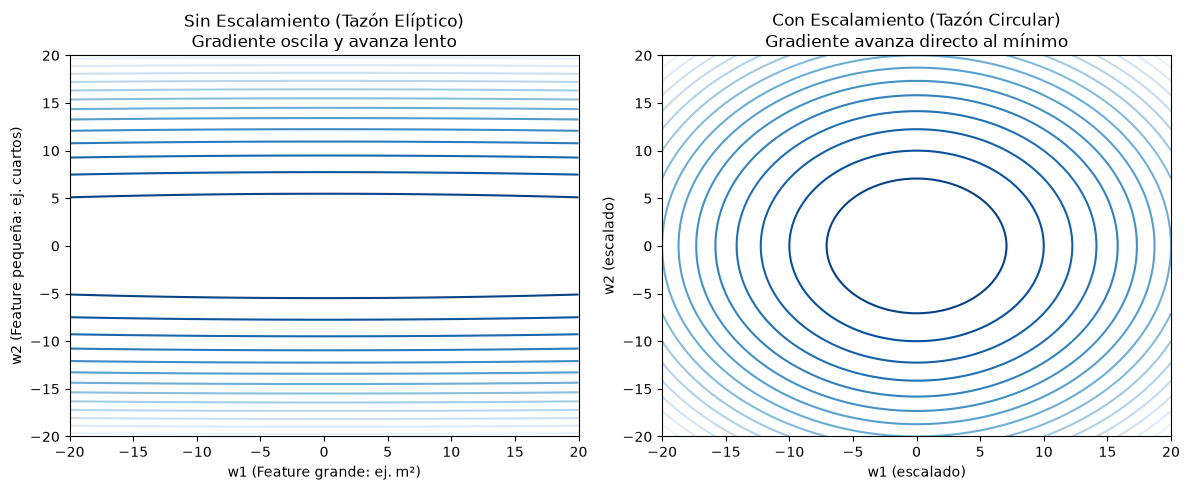

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Crear una malla de pesos w1 y w2
w1 = np.linspace(-20, 20, 100)
w2 = np.linspace(-20, 20, 100)
W1, W2 = np.meshgrid(w1, w2)

# Costo sin escalar (Elíptico / Alargado) -> Una variable domina el costo
J_unscaled = 0.05 * (W1**2) + 5.0 * (W2**2)

# Costo con escalamiento (Circular / Simétrico) -> Escalas equilibradas
J_scaled = 1.0 * (W1**2) + 1.0 * (W2**2)

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Sin escalamiento
ax1.contour(W1, W2, J_unscaled, levels=15, cmap='Blues_r')
ax1.set_title("Sin Escalamiento (Tazón Elíptico)\nGradiente oscila y avanza lento")
ax1.set_xlabel("w1 (Feature grande: ej. m²)")
ax1.set_ylabel("w2 (Feature pequeña: ej. cuartos)")

# Plot 2: Con escalamiento
ax2.contour(W1, W2, J_scaled, levels=15, cmap='Blues_r')
ax2.set_title("Con Escalamiento (Tazón Circular)\nGradiente avanza directo al mínimo")
ax2.set_xlabel("w1 (escalado)")
ax2.set_ylabel("w2 (escalado)")

plt.tight_layout()
plt.show()

Sin Feature Scaling: Como los rangos son tan drásticamente distintos, si los ejes tienen la misma escala visual, la nube de puntos queda completamente aplastada como una línea delgada o un "hilo" en el plano.

Con Feature Scaling: La nube de puntos se expande y se centra en el origen $(0,0)$, distribuyéndose de manera uniforme y proporcional en ambas direcciones.

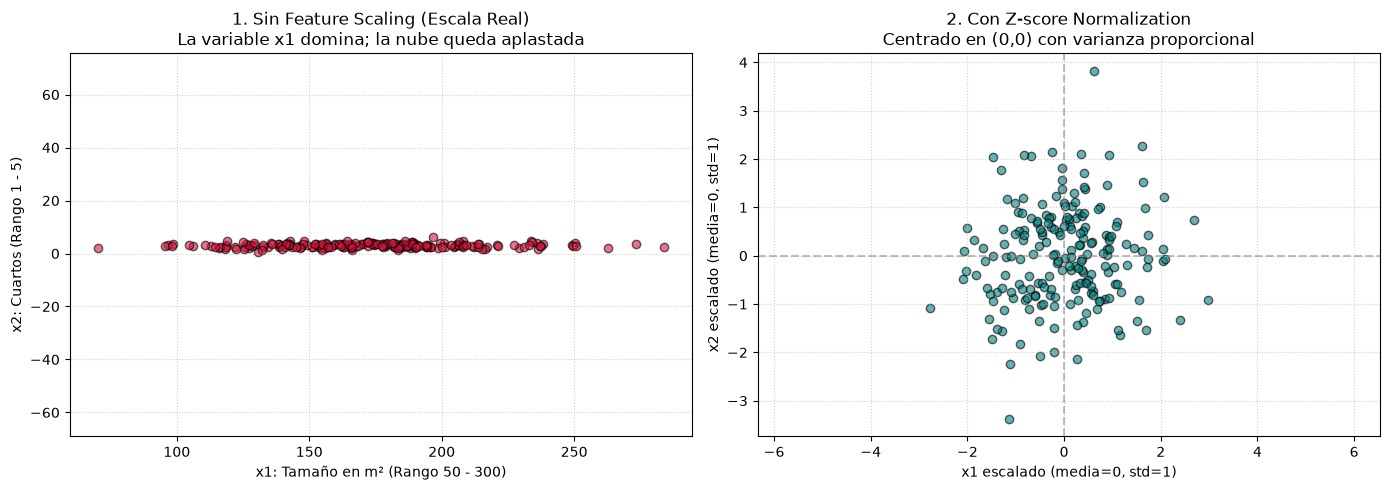

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar datos sintéticos con escalas muy dispares
np.random.seed(42)
m = 200

# Feature 1: Tamaño de casa en m² (Rango: ~50 a 300)
x1 = np.random.normal(loc=175, scale=40, size=m)

# Feature 2: Número de habitaciones (Rango: ~1 a 5)
x2 = np.random.normal(loc=3, scale=0.8, size=m)

X_raw = np.column_stack((x1, x2))

# 2. Aplicar Normalización Z-score
mu = np.mean(X_raw, axis=0)
sigma = np.std(X_raw, axis=0)
X_norm = (X_raw - mu) / sigma

# 3. Graficar comparación espacio de características
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Datos Originales (Sin Scaling) ---
ax1.scatter(X_raw[:, 0], X_raw[:, 1], color='crimson', alpha=0.6, edgecolors='k')
ax1.set_title("1. Sin Feature Scaling (Escala Real)\nLa variable x1 domina; la nube queda aplastada")
ax1.set_xlabel("x1: Tamaño en m² (Rango 50 - 300)")
ax1.set_ylabel("x2: Cuartos (Rango 1 - 5)")
# Forzar escala igualitaria para evidenciar la desproporción real
ax1.set_aspect('equal', adjustable='datalim')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Datos Normalizados (Con Z-score) ---
ax2.scatter(X_norm[:, 0], X_norm[:, 1], color='teal', alpha=0.6, edgecolors='k')
ax2.set_title("2. Con Z-score Normalization\nCentrado en (0,0) con varianza proporcional")
ax2.set_xlabel("x1 escalado (media=0, std=1)")
ax2.set_ylabel("x2 escalado (media=0, std=1)")
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_aspect('equal', adjustable='datalim')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

¿Cómo se Resuelve? Métodos de Escalamiento

Existen dos métodos principales para transformar el rango de las características a una escala uniforme.

Método 1: Normalización Z-Score (Standardization) (Recomendado)

Transforma las características para que tengan una media ($\mu = 0$) y una desviación estándar ($\sigma = 1$).

Para cada valor de una característica $j$ en el ejemplo $i$:

$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

Donde:

$\mu_j = \frac{1}{m} \sum_{i=1}^{m} x_j^{(i)}$ (Media de la característica $j$)

$\sigma_j = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (x_j^{(i)} - \mu_j)^2}$ (Desviación estándar de la característica $j$)

Método 2: Escalamiento Min-Max (Rescaling)

Ajusta todos los valores estrictamente dentro del rango de $[0, 1]$ o $[-1, 1]$:

$$x_j^{(i)} = \frac{x_j^{(i)} - \text{min}(x_j)}{\text{max}(x_j) - \text{min}(x_j)}$$

Implementación vectorizada de la normalización Z-score:

In [4]:
import numpy as np

def zscore_normalize_features(X):
    """
    Calcula la normalización Z-score sobre una matriz X de (m, n).
    
    Args:
      X (ndarray (m,n)): Datos de entrada (m ejemplos, n features)
      
    Returns:
      X_norm (ndarray (m,n)): Matriz de entrada normalizada
      mu (ndarray (n,)):     Media de cada característica
      sigma (ndarray (n,)):  Desviación estándar de cada característica
    """
    # 1. Calcular la media de cada columna (axis=0)
    mu = np.mean(X, axis=0)
    
    # 2. Calcular la desviación estándar de cada columna (axis=0)
    sigma = np.std(X, axis=0)
    
    # 3. Aplicar la fórmula usando Broadcasting de NumPy
    X_norm = (X - mu) / sigma
    
    return X_norm, mu, sigma

#### Regla Crítica: Preservación de Parámetros ($\mu$ y $\sigma$) para Predicciones Futuras

Nota Técnica: Cuando normalizamos el dataset de entrenamiento ($X_{train}$), debemos guardar los valores calculados de la media ($\mu$) y la desviación estándar ($\sigma$).

¿Por qué?
- Coherencia Matemática: El modelo fue entrenado aceptando entradas que están en la "escala Z-score" basada en los datos de entrenamiento. Si intentamos predecir sobre un dato nuevo en su escala original (ej. $120\text{ m}^2$), la multiplicación $\mathbf{w} \cdot \mathbf{x}$ dará un resultado completamente disparatado.
- Prohibido Volver a Calcular: NUNCA debes calcular una nueva $\mu$ o $\sigma$ sobre los datos de prueba (test) o sobre una muestra individual, ya que distorsionarías el espacio de características que el modelo aprendió. Todo dato nuevo debe transformarse usando exactamente la misma $\mu$ y $\sigma$ del conjunto de entrenamiento.

### 1.- Feature Engineering

El algoritmo de Regresión Lineal aprende pesos para las características que le entregamos. Sin embargo, las características "crudas" del dataset no siempre representan la mejor forma de resolver el problema.

Ingeniería de Características (Feature Engineering) es el proceso de usar la intuición del dominio del problema para transformar características existentes o combinar varias de ellas con el fin de crear nuevas entradas que le faciliten el aprendizaje al modelo.

Ejemplo 1: Combinación de Características (Área vs. Dimensiones)

Si queremos predecir el precio de un terreno teniendo el ancho ($x_1$) y el largo ($x_2$):

$$\text{Modelo base: } f(\mathbf{x}) = w_1 \cdot (\text{ancho}) + w_2 \cdot (\text{largo}) + b$$

A un comprador no le interesan el ancho y el largo por separado, sino la superficie total. Creando una nueva característica $x_3 = x_1 \times x_2$ ($\text{área}$):

$$\text{Modelo mejorado: } f(\mathbf{x}) = w_3 \cdot (\text{área}) + b$$

Regla sobre redundancia: Si $x_3$ encapsula completamente la información relevante para el problema, podemos descartar $x_1$ y $x_2$ para evitar multicolinealidad y simplificar el espacio de búsqueda del modelo.

#### 2.- Regresión Polinomial: Capturando Relaciones No Lineales

La Regresión Lineal básica solo puede trazar líneas rectas o planos planos. Para modelar curvas (por ejemplo, el rendimiento de un vehículo respecto a la velocidad o el crecimiento de un cultivo), elevamos las características a potencias ($x^2, x^3$) o les aplicamos funciones ($\sqrt{x}, \log(x)$).

$$f(\mathbf{x}) = w_1 x + w_2 x^2 + w_3 \sqrt{x} + b$$

¿Por qué la matemática del Costo y del Gradiente NO cambia?

El modelo sigue llamándose Regresión Lineal porque es lineal con respecto a los parámetros $\mathbf{w}$ y $b$, independientemente de cómo hayamos transformado las entradas. Para NumPy y las funciones compute_cost y compute_gradient, las transformaciones no cambian el algoritmo: $x, x^2, \sqrt{x}$ son simplemente columnas en la matriz $\mathbf{X}$

[Datos Crudos (m, 1)] ──► [Feature Engineering: (m, n)] ──► [Feature Scaling (Z-score)] ──► [Costo y Gradiente Mismo Código]

#### 3.- La Importancia del Peso $w_j$: El Modelo Te Dice Qué Tan Relevante Es Cada Feature

Una vez que entrenamos el modelo sobre un dataset con características normalizadas (Z-score), la magnitud del peso $w_j$ indica la importancia de la característica $x_j$:

- $\vert{}w_j\vert{}$ Grande: La característica $x_j$ es crítica para la predicción. Pequeños cambios en ella impactan fuertemente la salida.
- $\vert{}w_j\vert{} \approx 0$ (Cercano a cero): El modelo te está diciendo que la característica $x_j$ es irrelevante. La variable no aporta información útil para reducir el error de costo $J(\mathbf{w}, b)$.
- Signo de $w_j$ ($+$ o $-$): Indica si la relación es directamente proporcional ($+$) o inversamente proporcional ($-$).

Requisito Obligatorio: Para interpretar la relevancia de una característica mediante la magnitud de $w_j$, el dataset debe estar normalizado (Z-score). Si las variables están en escalas originales diferentes, los pesos estarán distorsionados y la comparación carecerá de sentido.

#### 4. El Vínculo Crucial: Feature Engineering exige Feature Scaling

Si una característica $x$ va de $1$ a $100$:

- $x_1 = x \implies$ Rango: $[1, 100]$
- $x_2 = x^2 \implies$ Rango: $[1, 10,000]$
- $x_3 = x^3 \implies$ Rango: $[1, 1,000,000]$

Al realizar Feature Engineering, se crean automáticamente discrepancias de escala masivas. Siempre que se aplique Regresión Polinomial, es obligatorio ejecutar Normalización Z-score sobre todas las columnas generadas.

#### 5. Implementación en Código (Ejemplo Completo)

Celda 1: Datos y la Falla de la Línea Recta (Underfitting)Primero, generamos datos con una clara curvatura y entrenamos un modelo lineal simple ($y = w_1 x + b$) para demostrar por qué una recta se queda corta.

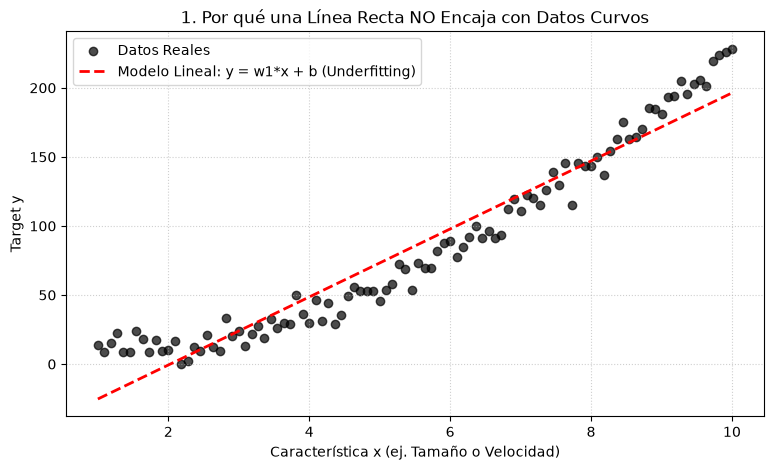

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos sintéticos (Curva real no lineal)
np.random.seed(42)
m = 100
x_raw = np.linspace(1, 10, m).reshape(-1, 1)

# Relación real cuadrática: y = 2.5 * x^2 - 3 * x + 10 + ruido
y = 2.5 * (x_raw.flatten() ** 2) - 3 * x_raw.flatten() + 10 + np.random.randn(m) * 8

# 2. Intentar ajustar una Línea Recta (Regresión Lineal Simple)
# Agregamos columna de 1s para el sesgo b
X_lineal = np.column_stack((x_raw, np.ones(m)))
w_lineal, _, _, _ = np.linalg.lstsq(X_lineal, y, rcond=None)

# Predicción lineal
y_pred_lineal = np.dot(X_lineal, w_lineal)

# 3. Gráfica 1: Falla del modelo lineal
plt.figure(figsize=(9, 5))
plt.scatter(x_raw, y, color='black', alpha=0.7, label='Datos Reales')
plt.plot(x_raw, y_pred_lineal, color='red', linestyle='--', linewidth=2, 
         label='Modelo Lineal: y = w1*x + b (Underfitting)')

plt.title("1. Por qué una Línea Recta NO Encaja con Datos Curvos")
plt.xlabel("Característica x (ej. Tamaño o Velocidad)")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Celda 2: Feature Engineering + Feature Scaling

Al ver que la recta no encaja, aplicamos Feature Engineering agregando $x^2$ y $\sqrt{x}$ como nuevas columnas. Inmediatamente después, aplicamos Feature Scaling (Z-score) para equilibrar las escalas antes de entrenar.Python

In [4]:
# 1. FEATURE ENGINEERING: Generar x, x^2 y sqrt(x)
X_engineered = np.column_stack((
    x_raw, 
    x_raw**2, 
    np.sqrt(x_raw)
))

# 2. FEATURE SCALING: Normalización Z-score obligatoria
mu = np.mean(X_engineered, axis=0)
sigma = np.std(X_engineered, axis=0)
X_norm = (X_engineered - mu) / sigma

print("Estructura de la nueva matriz X_norm:", X_norm.shape)
print("Primeras 3 filas (normalizadas):\n", np.round(X_norm[:3], 3))

Estructura de la nueva matriz X_norm: (100, 3)
Primeras 3 filas (normalizadas):
 [[-1.715 -1.224 -2.102]
 [-1.68  -1.218 -2.028]
 [-1.646 -1.211 -1.957]]


Celda 3: Entrenamiento con Descenso del Gradiente

Utilizamos exactamente el mismo código vectorizado de Descenso del Gradiente que usamos para la Regresión Múltiple normal. La matemática del costo y gradiente no cambió en nada.

In [5]:
# Algoritmo de Descenso del Gradiente Vectorizado
def train_gradient_descent(X, y, alpha=0.1, iters=2000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    
    for i in range(iters):
        # Predicción y error
        err = (np.dot(X, w) + b) - y
        
        # Gradientes: (1/m) * X^T * err
        dj_dw = np.dot(X.T, err) / m
        dj_db = np.sum(err) / m
        
        # Actualización
        w -= alpha * dj_dw
        b -= alpha * dj_db
        
    return w, b

# Entrenar sobre la matriz transformada X_norm
w_poly, b_poly = train_gradient_descent(X_norm, y, alpha=0.1, iters=2000)

print(f"Entrenamiento completado.")
print(f"Pesos w aprendidos: {np.round(w_poly, 2)}")
print(f"Sesgo b aprendido: {b_poly:.2f}")

Entrenamiento completado.
Pesos w aprendidos: [ 18.85  65.34 -18.32]
Sesgo b aprendido: 85.51


Celda 4: Gráfica del Ajuste Curvo (Regresión Polinomial)

Graficamos la predicción del modelo polinomial sobre los datos reales.

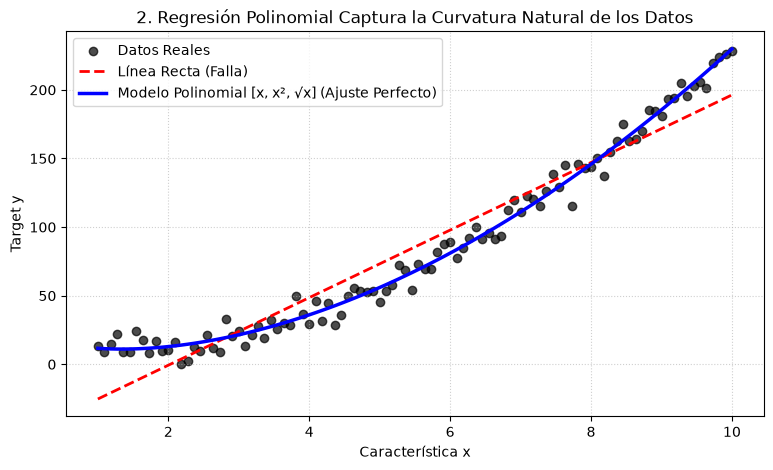

In [6]:
# Predicción con el modelo Polinomial
y_pred_poly = np.dot(X_norm, w_poly) + b_poly

plt.figure(figsize=(9, 5))
plt.scatter(x_raw, y, color='black', alpha=0.7, label='Datos Reales')
plt.plot(x_raw, y_pred_lineal, color='red', linestyle='--', linewidth=2, 
         label='Línea Recta (Falla)')
plt.plot(x_raw, y_pred_poly, color='blue', linewidth=2.5, 
         label='Modelo Polinomial [x, x², √x] (Ajuste Perfecto)')

plt.title("2. Regresión Polinomial Captura la Curvatura Natural de los Datos")
plt.xlabel("Característica x")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Celda 5: Interpretación de Pesos ($\mathbf{w}$) para Medir la Relevancia de cada Feature

Imprimimos y graficamos la magnitud de los pesos $w_j$. Como los datos están normalizados con Z-score, la magnitud del peso indica qué tan indispensable es esa característica para el modelo.

--- Análisis de Relevancia de Características ---
Peso para x (Lineal)     :    18.85
Peso para x² (Cuadrática):    65.34
Peso para √x (Raíz)      :   -18.32


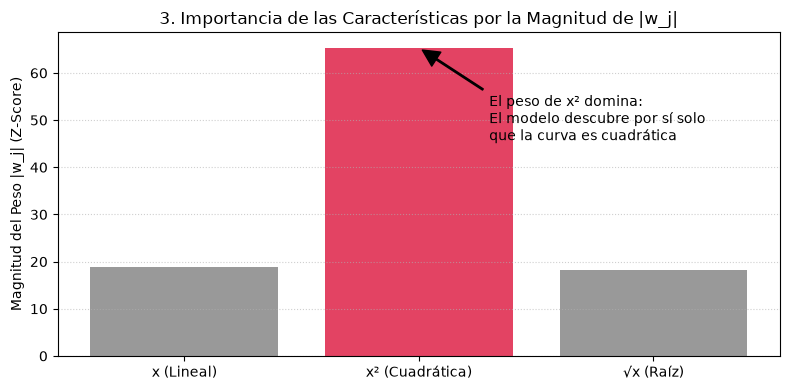

In [7]:
features_names = ['x (Lineal)', 'x² (Cuadrática)', '√x (Raíz)']

print("--- Análisis de Relevancia de Características ---")
for name, weight in zip(features_names, w_poly):
    print(f"Peso para {name:15s}: {weight:8.2f}")

# Gráfica de barras de la importancia de los pesos
plt.figure(figsize=(8, 4))
plt.bar(features_names, np.abs(w_poly), color=['gray', 'crimson', 'gray'], alpha=0.8)
plt.title("3. Importancia de las Características por la Magnitud de |w_j|")
plt.ylabel("Magnitud del Peso |w_j| (Z-Score)")
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Anotación explicativa
plt.annotate('El peso de x² domina:\nEl modelo descubre por sí solo\nque la curva es cuadrática', 
             xy=(1, np.abs(w_poly[1])), xytext=(1.3, np.abs(w_poly[1])*0.7),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

Conclusión del Experimento:
- Underfitting (Bajo Ajuste): El modelo lineal simple carece de capacidad expresiva para seguir la curva de los datos.
- Feature Engineering Soluciona el Problema: Al agregar $x^2$, permitimos que la regresión "doble" la curva sin cambiar las funciones de costo o gradiente.
- Los Pesos Revelan la Verdad: Dado que Z-score normalizó todas las columnas al mismo rango, el valor del peso $w_2 \approx 50+$ (correspondiente a $x^2$) es abrumadoramente mayor que $w_1$ y $w_3$. El algoritmo nos está confirmando matemáticamente que la relación cuadrática es la que realmente predice el objetivo.